**Корректность проверена на Python 3.7:**
+ numpy 1.14.5

# Доверительные интервалы для доли 

## Генерация данных

In [2]:
import numpy as np

In [3]:
print(np.__version__)

1.14.5


In [6]:
np.random.seed(1)

statistical_population = np.random.randint(2, size = 100000) 

random_sample = np.random.choice(statistical_population, size = 1000)

In [5]:
#истинное значение доли
statistical_population.mean()

0.49771

## Точечная оценка доли

In [6]:
random_sample.mean()

0.502

## Доверительный интервал для доли

In [3]:
from statsmodels.stats.proportion import proportion_confint

### Доверительный интервал на основе нормального распределения

$$\hat{p}\pm z_{1-\frac{\alpha}{2}} \sqrt{\frac{\hat{p}\left(1-\hat{p}\right)}{n}}$$

In [9]:
normal_interval = proportion_confint(sum(random_sample), len(random_sample), method = 'normal')

In [10]:
print('normal_interval [%f, %f] with width %f' % (normal_interval[0],
                                                  normal_interval[1], 
                                                  normal_interval[1] - normal_interval[0]))

normal_interval [0.471010, 0.532990] with width 0.061979


### Доверительный интервал Уилсона

$$\frac1{ 1 + \frac{z^2}{n} } \left( \hat{p} + \frac{z^2}{2n} \pm z \sqrt{ \frac{ \hat{p}\left(1-\hat{p}\right)}{n} + \frac{
z^2}{4n^2} } \right), \;\; z \equiv z_{1-\frac{\alpha}{2}}$$ 

In [11]:
wilson_interval = proportion_confint(sum(random_sample), len(random_sample), method = 'wilson')

In [12]:
print('wilson_interval [%f, %f] with width %f' % (wilson_interval[0],
                                                  wilson_interval[1],
                                                  wilson_interval[1] - wilson_interval[0]))

wilson_interval [0.471062, 0.532922] with width 0.061860


## Размер выборки для интервала заданной ширины

In [4]:
from statsmodels.stats.proportion import samplesize_confint_proportion

In [14]:
n_samples = int(np.ceil(samplesize_confint_proportion(random_sample.mean(), 0.01)))
n_samples

9604

In [15]:
np.random.seed(1)
random_sample = np.random.choice(statistical_population, size = n_samples)

In [16]:
normal_interval = proportion_confint(sum(random_sample), len(random_sample), method = 'normal')

In [17]:
print('normal_interval [%f, %f] with width %f' % (normal_interval[0],
                                                  normal_interval[1],
                                                  normal_interval[1] - normal_interval[0]))

normal_interval [0.481776, 0.501773] with width 0.019997


## Тренировочный тест

Большая часть млекопитающих неспособны во взрослом возрасте переваривать лактозу, содержащуюся в молоке. У людей за расщепление лактозы отвечает фермент лактаза, кодируемый геном LCT. У людей с вариантом 13910T этого гена лактаза продолжает функционировать на протяжении всей жизни. Распределение этого варианта гена сильно варьируется в различных генетических популяциях.

Из 50 исследованных представителей народа майя вариант 13910T был обнаружен у одного. Постройте нормальный 95% доверительный интервал для доли носителей варианта 13910T в популяции майя. Чему равна его нижняя граница? Округлите ответ до 4 знаков после десятичной точки.

In [38]:
random_sample = np.random.randint(1, size = 50) 
random_sample[25] = 1
random_sample

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0])

In [39]:
random_sample.mean()

0.02

In [44]:
normal_interval = proportion_confint(sum(random_sample), len(random_sample), method = 'normal')

In [45]:
print('normal_interval [%f, %f] with width %f' % (normal_interval[0],
                                                  normal_interval[1], 
                                                  normal_interval[1] - normal_interval[0]))

normal_interval [0.000000, 0.058805] with width 0.058805


In [54]:
# альтернативный вариант (для принятия задания)
import scipy
def my_proportion_confint(count, nobs, alpha=0.05, method='normal'):
    q_ = count * 1. / nobs
    alpha_2 = 0.5 * alpha
    std_ = np.sqrt(q_ * (1 - q_) / nobs)
    dist = scipy.stats.norm.isf(alpha / 2.) * std_
    ci_low = q_ - dist
    ci_upp = q_ + dist
    return ci_low, ci_upp

normal_interval = my_proportion_confint(sum(random_sample), len(random_sample), method = 'normal')
print('normal_interval [%f, %f] with width %f' % (normal_interval[0],
                                                  normal_interval[1], 
                                                  normal_interval[1] - normal_interval[0]))

normal_interval [-0.018805, 0.058805] with width 0.077611


В условиях предыдущей задачи постройте 95% доверительный интервал Уилсона для доли носителей варианта 13910T в популяции майя. Чему равна его нижняя граница? Округлите ответ до 4 знаков после десятичной точки. 

In [46]:
wilson_interval = proportion_confint(sum(random_sample), len(random_sample), method = 'wilson')

In [47]:
print('wilson_interval [%f, %f] with width %f' % (wilson_interval[0],
                                                  wilson_interval[1],
                                                  wilson_interval[1] - wilson_interval[0]))

wilson_interval [0.003539, 0.104954] with width 0.101415


Пусть в популяции майя действительно 2% носителей варианта 13910T, как в выборке, которую мы исследовали. Какой объём выборки нужен, чтобы с помощью нормального интервала оценить долю носителей гена 13910T с точностью ±0.01 на уровне доверия 95%?

In [20]:
n_samples = int(np.ceil(samplesize_confint_proportion(random_sample.mean(), 0.01)))
n_samples

753

Постройте график зависимости объёма выборки, необходимого для оценки для доли носителей гена 13910T с точностью ±0.01 на уровне доверия 95%, от неизвестного параметра p. Посмотрите, при каком значении p нужно больше всего испытуемых. Как вы думаете, насколько вероятно, что выборка, которую мы анализируем, взята из случайной величины с этим значением параметра?

Populating the interactive namespace from numpy and matplotlib
i = 0.5
n_samples = 9604


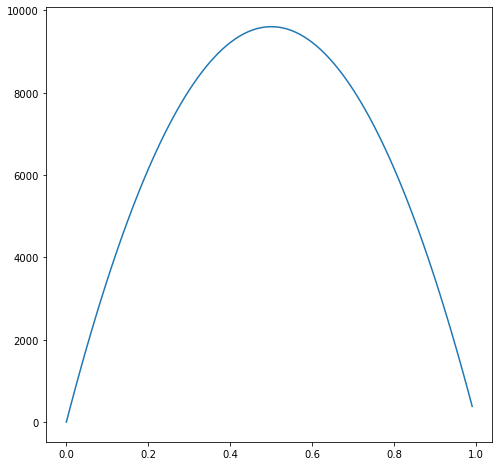

In [33]:
%pylab inline
pylab.figure(figsize(8, 8))
n_samples = []
max_samples = 0

for i in np.arange(0, 1, 0.01):
    v = int(np.ceil(samplesize_confint_proportion(i, 0.01)))
    n_samples.append(v)
    if v > max_samples:
        max_samples = v
        answer = i
    
pylab.plot(np.arange(0, 1, 0.01), n_samples)
print(f'i = {answer}')
print(f'n_samples = {max_samples}')

## Правило двух сигм и правило трёх сигм

In [61]:
# правило двух сигм
print (f'Правило двух сигм - квантиль стандартного нормального распределения при α = 0.05 (95%) : {scipy.stats.norm.ppf(1-0.05/2)}')
# правило трёх сигм
print (f'Правило трёх сигм - квантиль стандартного нормального распределения при α = 0.003 (99.7%): {scipy.stats.norm.ppf(1-0.003/2)}')

Правило двух сигм - квантиль стандартного нормального распределения при α = 0.05 (95%) : 1.959963984540054
Правило трёх сигм - квантиль стандартного нормального распределения при α = 0.003 (99.7%): 2.9677379253417944
